<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 3: 모델 추가 학습**

## **미션 설명**

- 이번 단계에서는 다음과 같이 3개의 미션을 수행합니다.

### 미션 8: 전처리 파이프라인 만들기

- 새로운 학습용/검증용 데이터에 대해 매번 전처리 작업을 수행해야 합니다.
- 반복되는 전처리 작업은 비효율적인 업무 중 하나입니다.
- 이러한 문제를 해결하기 위해 다음과 같은 처리를 일괄 수행하는 파이프라인 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등

### 미션 9: 기본 모델로 예측 및 평가

- 이전 과정에서 만든 모델이 기본 모델(Base Model)입니다.
- 새로 전달 받은 평가용 데이터로 기존에 만든 모델의 성능을 평가해봅니다.

### 미션 10: 추가 학습

- 문제 상황에 맞게 가장 적절한 방법으로 모델 추가 학습을 진행합니다.
- 추가 학습 후 이전에 평가했던 새로운 평가 데이터로 다시 평가해 성능 향상을 확인합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [1]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [3]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [4]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [5]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [6]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)


In [7]:
# 함수 만들기
def build_model_input(data):

  # 1. 결측치 처리
  num_cols = data.select_dtypes(include=['number']).columns
  data[num_cols] = data[num_cols].fillna(data[num_cols].median())

  cat_cols = data.select_dtypes(include=['object', 'category']).columns
  data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])


  # 2. 값 변경
  data['Satisfaction'] = data['Satisfaction'].map({
      'Satisfied': 1,
      'Neutral or Dissatisfied': 0
  })


  # 3. 변수 제거
  rmv_cols = ['Unnamed: 0', 'ID']
  data.drop(columns=rmv_cols, inplace=True)


  # 4. 라벨 인코딩
  # 문자열 변수 리스트로 선언
  cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

  for col in cat_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])


  # 5. 가변수화
  # 설문 범주 정의
  categories = [0, 1, 2, 3, 4, 5]

  # 가변수화 대상 변수
  dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
             'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
             'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

  # Category 형 변수로 변환
  for col in dumm_cols:
    data[col] = pd.Categorical(data[col], categories=categories)

  # 가변수화
  data = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)


  # 6. x, y 분리
  target = 'Satisfaction'
  x = data.drop(target, axis=1)
  y = data.loc[:, target]


  # 7. 스케일링
  x = scaler.transform(x)


  # 반환
  return x, y

- 점검: 다음 구문이 잘 수행되어 x_val, y_val이 분리되어야 합니다.


In [8]:
# x_val, y_val 나누기
x_val, y_val = build_model_input(new_test)

# 확인
print(x_val.shape)
print(y_val.shape)

(350, 78)
(350,)


## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [9]:
#위에서 진행

### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

In [10]:
# 예측
y_pred = base_model.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

# 평가
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
[[154  37]
 [  1 158]]
              precision    recall  f1-score   support

           0       0.99      0.81      0.89       191
           1       0.81      0.99      0.89       159

    accuracy                           0.89       350
   macro avg       0.90      0.90      0.89       350
weighted avg       0.91      0.89      0.89       350



## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- new_train 데이터프레임을 x_train, y_train으로 분리합니다.

In [12]:
x_train, y_train = build_model_input(new_train)

print(x_train.shape)
print(y_train.shape)


(850, 78)
(850,)


### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

In [13]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x_train.shape[1]

# Sequential 모델 선언
model4 = Sequential([
    Input(shape=(nfeatures, )),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 모델 요약
model4.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,681 (30.00 KB)

 Trainable params: 7,681 (30.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [14]:
#학습 설정
model4.compile(optimizer=Adam(learning_rate=0.002), loss='binary_crossentropy')
#모델 학습
es = EarlyStopping(monitor='val_loss', min_delta=0.0005, patience=12, restore_best_weights=True, verbose=1)
hist = model4.fit(x_train, y_train, epochs=100, validation_split=0.2, batch_size=16, callbacks=[es], verbose=1).history


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.5919 - val_loss: 0.4614
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3573 - val_loss: 0.3256
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2651 - val_loss: 0.2945
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2122 - val_loss: 0.2697
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1976 - val_loss: 0.2469
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1695 - val_loss: 0.2279
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1516 - val_loss: 0.2319
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1452 - val_loss: 0.2345
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1108 - val_loss: 0.2515
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0893 - val_loss: 0.2730
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0800 - val_loss: 0.2515
Epoch 12/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

- 학습 곡선을 확인합니다.

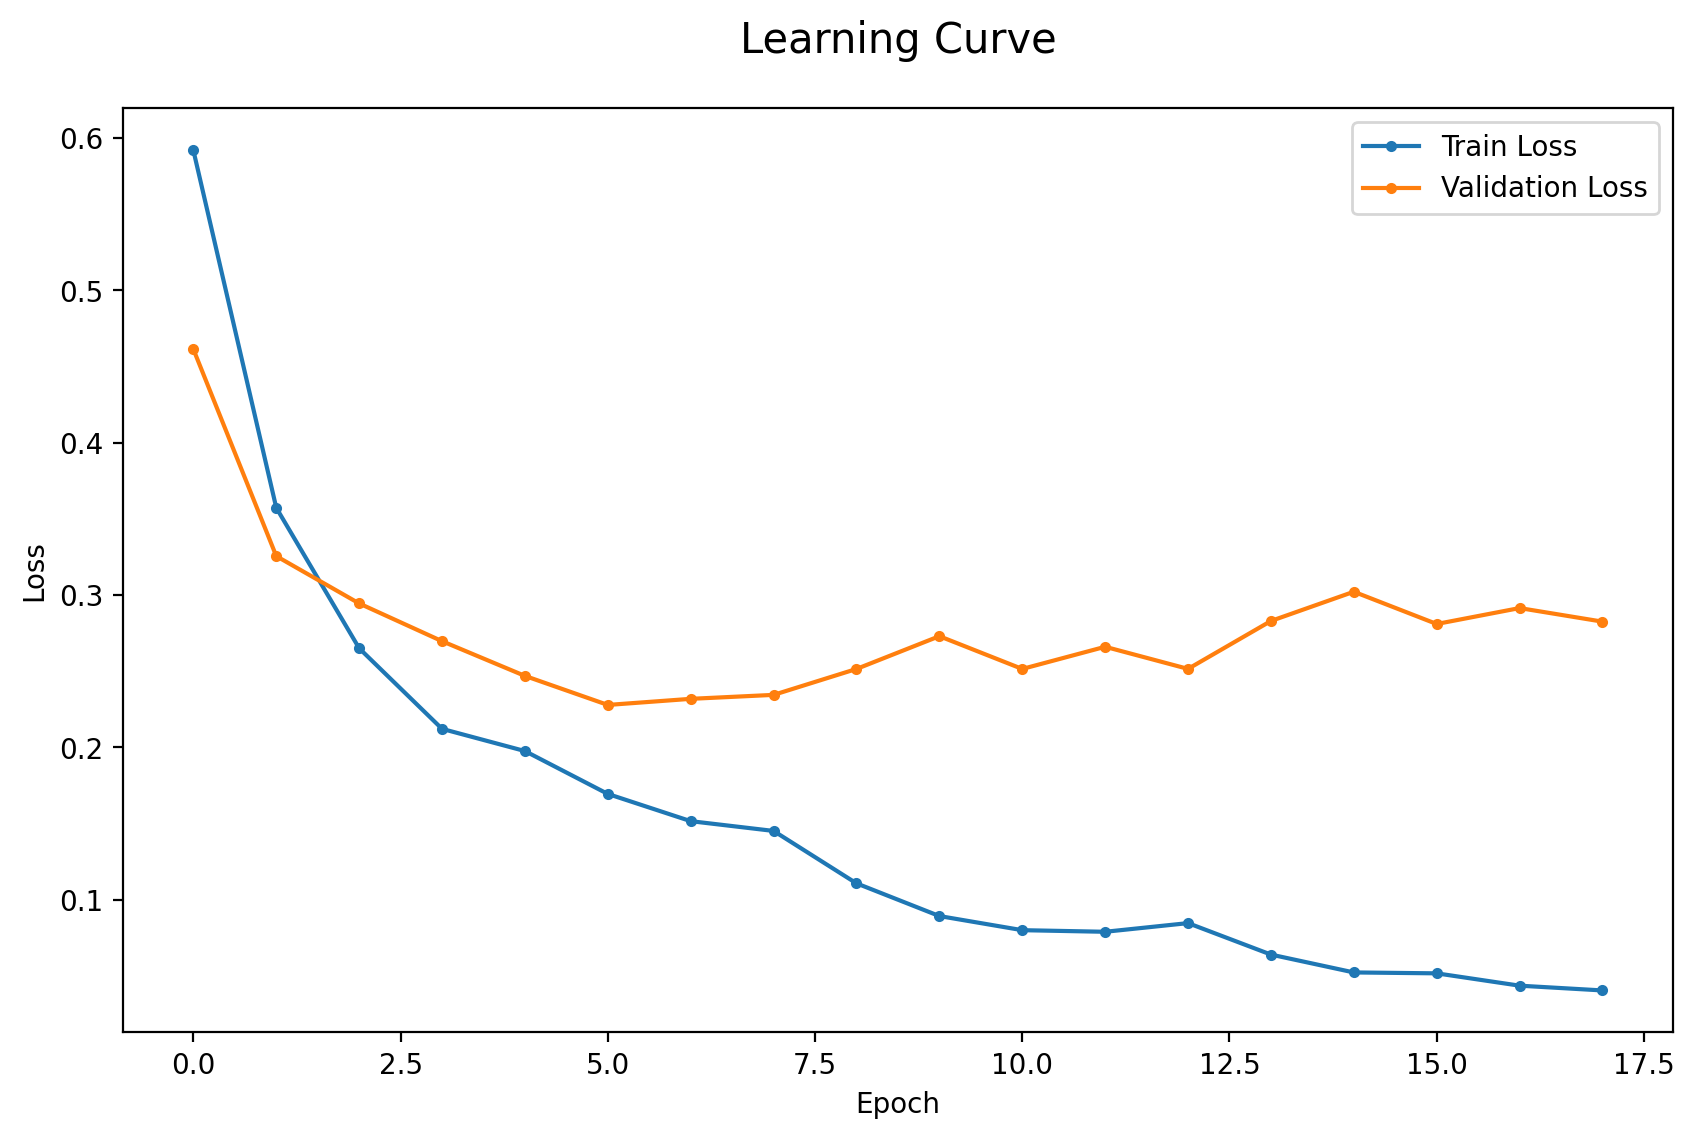

In [15]:
dl_history_plot(hist)


- 검증 데이터로 예측 및 평가를 수행합니다.

In [16]:
#예측
y_pred = model4.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

# 평가
print(classification_report(y_val, y_pred))


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       191
           1       0.93      0.86      0.89       159

    accuracy                           0.90       350
   macro avg       0.91      0.90      0.90       350
weighted avg       0.90      0.90      0.90       350



In [30]:
# 의견
# 이전 기본 모델(base_model)은 한쪽 클래스에 조금 더 치우친 느낌이었으나,
# 이번 모델은 precision, recall, f1-score가 두 클래스에서 비교적 고르게 나왔다.
# 따라서, 특정 클래스에 편향되지 않은 안정적인 예측이 이루어졌다고 판단할 수 있다.

### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

In [17]:
model = base_model


- 학습 방법을 설정하고 학습을 수행합니다.

In [18]:
# 학습 설정
# model.compile(optimizer=Adam(learning_rate=0.002), loss='binary_crossentropy')
# es = EarlyStopping(monitor='val_loss', min_delta=0.0005, patience=12, restore_best_weights=True, verbose=1)
# 모델 학습
hist = model.fit(x_train, y_train, epochs=100, validation_split=0.2, batch_size=16, callbacks=[es], verbose=1).history


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1764 - val_loss: 0.1303
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1230 - val_loss: 0.1328
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0888 - val_loss: 0.1404
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0721 - val_loss: 0.1332
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0606 - val_loss: 0.1383
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0600 - val_loss: 0.1356
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0578 - val_loss: 0.1479
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0387 - val_loss: 0.1455
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0332 - val_loss: 0.1628
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0276 - val_loss: 0.1736
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0323 - val_loss: 0.1802
Epoch 12/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0

- 학습 곡선을 확인합니다.

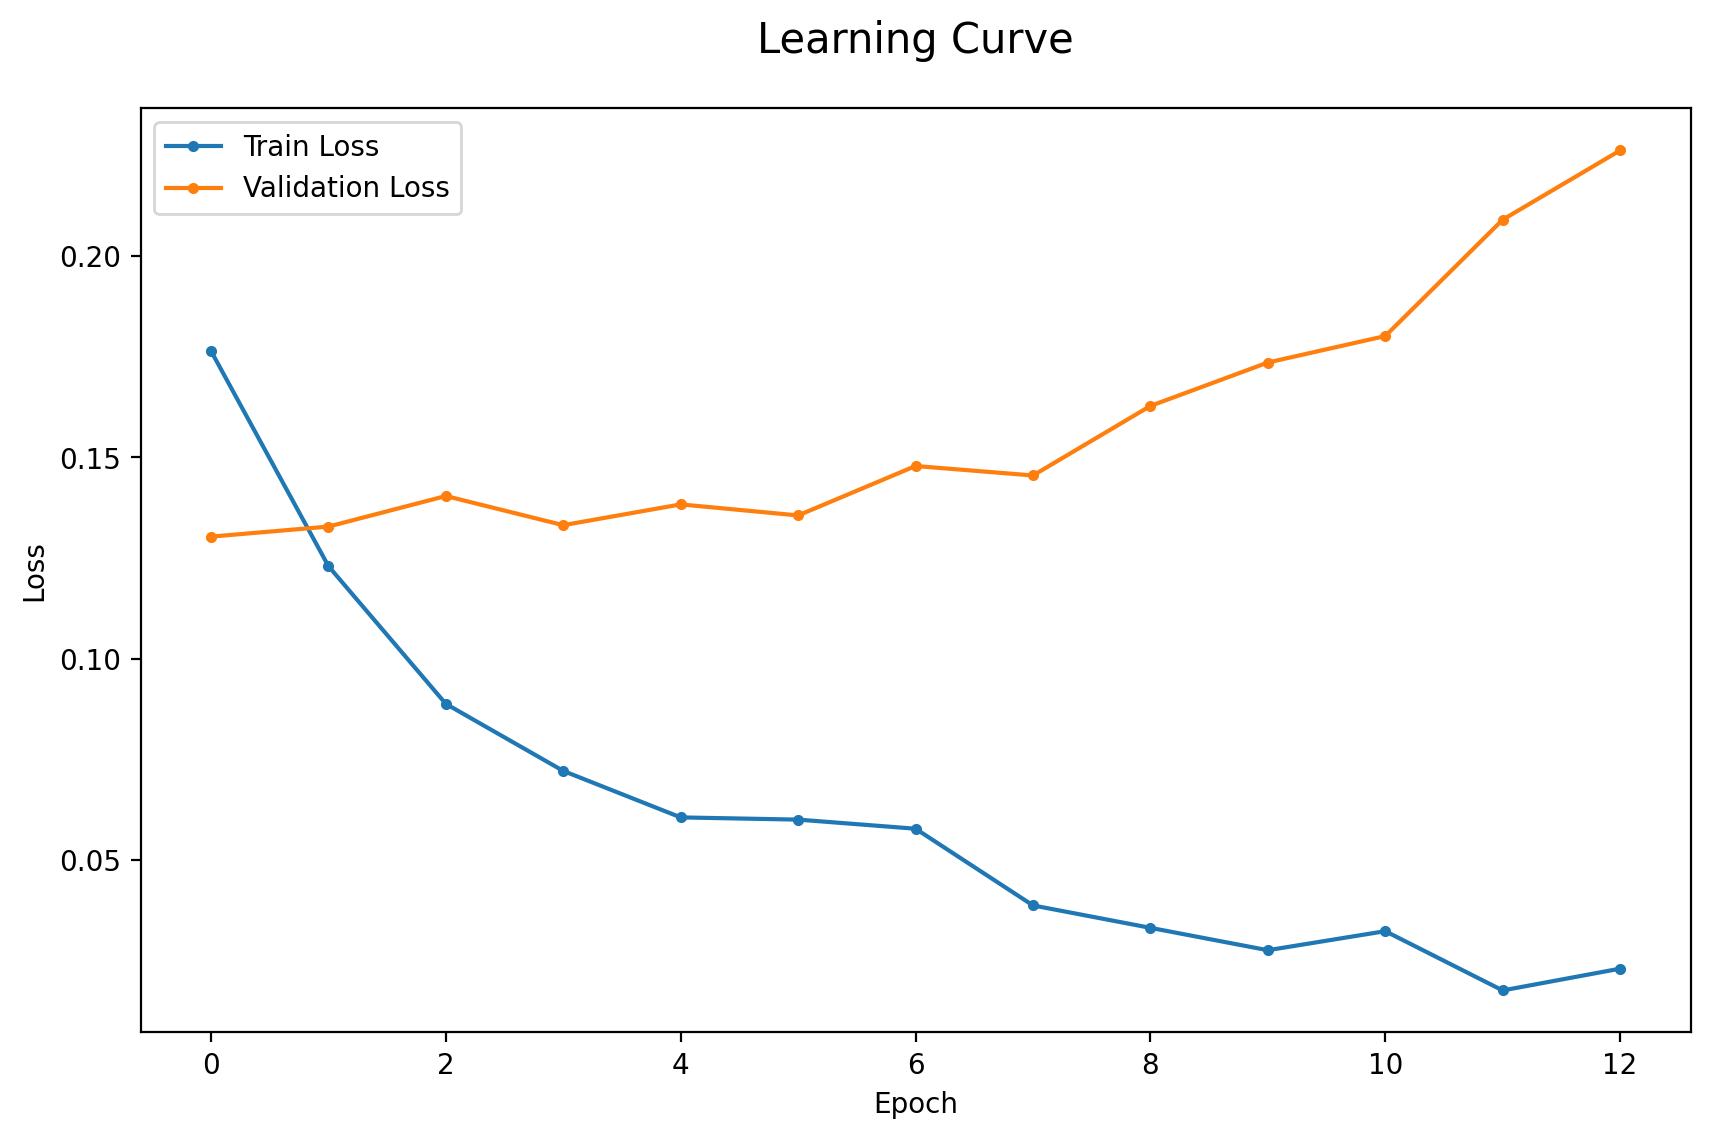

In [19]:
# 학습 곡선
dl_history_plot(hist)


- 검증 데이터로 예측 및 평가를 수행합니다.

In [20]:
# 예측
y_pred = model.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [21]:
# 평가
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       191
           1       0.89      0.95      0.92       159

    accuracy                           0.92       350
   macro avg       0.92      0.93      0.92       350
weighted avg       0.92      0.92      0.92       350



In [28]:
# 의견
# 클래스 0과 클래스 1 모두 precision, recall, f1-score가 0.90 이상으로 나타나
# 전반적으로 우수하고 균형잡힌 성능을 보였다.
# 오분류 수가 이전 모델보다 감소해, 추가 학습이 실제 예측 성능 향상에 긍정적인 영향을 준 것으로 판단된다.

### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [22]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

# 마지막 레이어 제거
base_model.pop()

<Dense name=dense_3, built=True>

In [23]:
# 메모리 정리
clear_session()

for layer in base_model.layers[:-3]:
  layer.trainable = False

# 모델 선언
model = Sequential([
    base_model,
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 모델 요약
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 16)             │         7,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,809 (30.50 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 5,056 (19.75 KB)

- 학습 방법을 설정하고 학습을 수행합니다.

In [24]:
# 학습 설정
model.compile(optimizer=Adam(learning_rate=0.002), loss='binary_crossentropy')
es = EarlyStopping(monitor='val_loss', min_delta=0.0005, patience=12, restore_best_weights=True, verbose=1)

# 모델 학습
hist = model.fit(x_train, y_train, epochs=100, validation_split=0.2, batch_size=16, callbacks=[es], verbose=1).history


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4947 - val_loss: 0.3796
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2876 - val_loss: 0.1886
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1692 - val_loss: 0.1372
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1525 - val_loss: 0.1309
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1325 - val_loss: 0.1293
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1326 - val_loss: 0.1291
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1233 - val_loss: 0.1312
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1286 - val_loss: 0.1294
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1169 - val_loss: 0.1282
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1135 - val_loss: 0.1287
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1344 - val_loss: 0.1276
Epoch 12/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1

- 학습 곡선을 확인합니다.

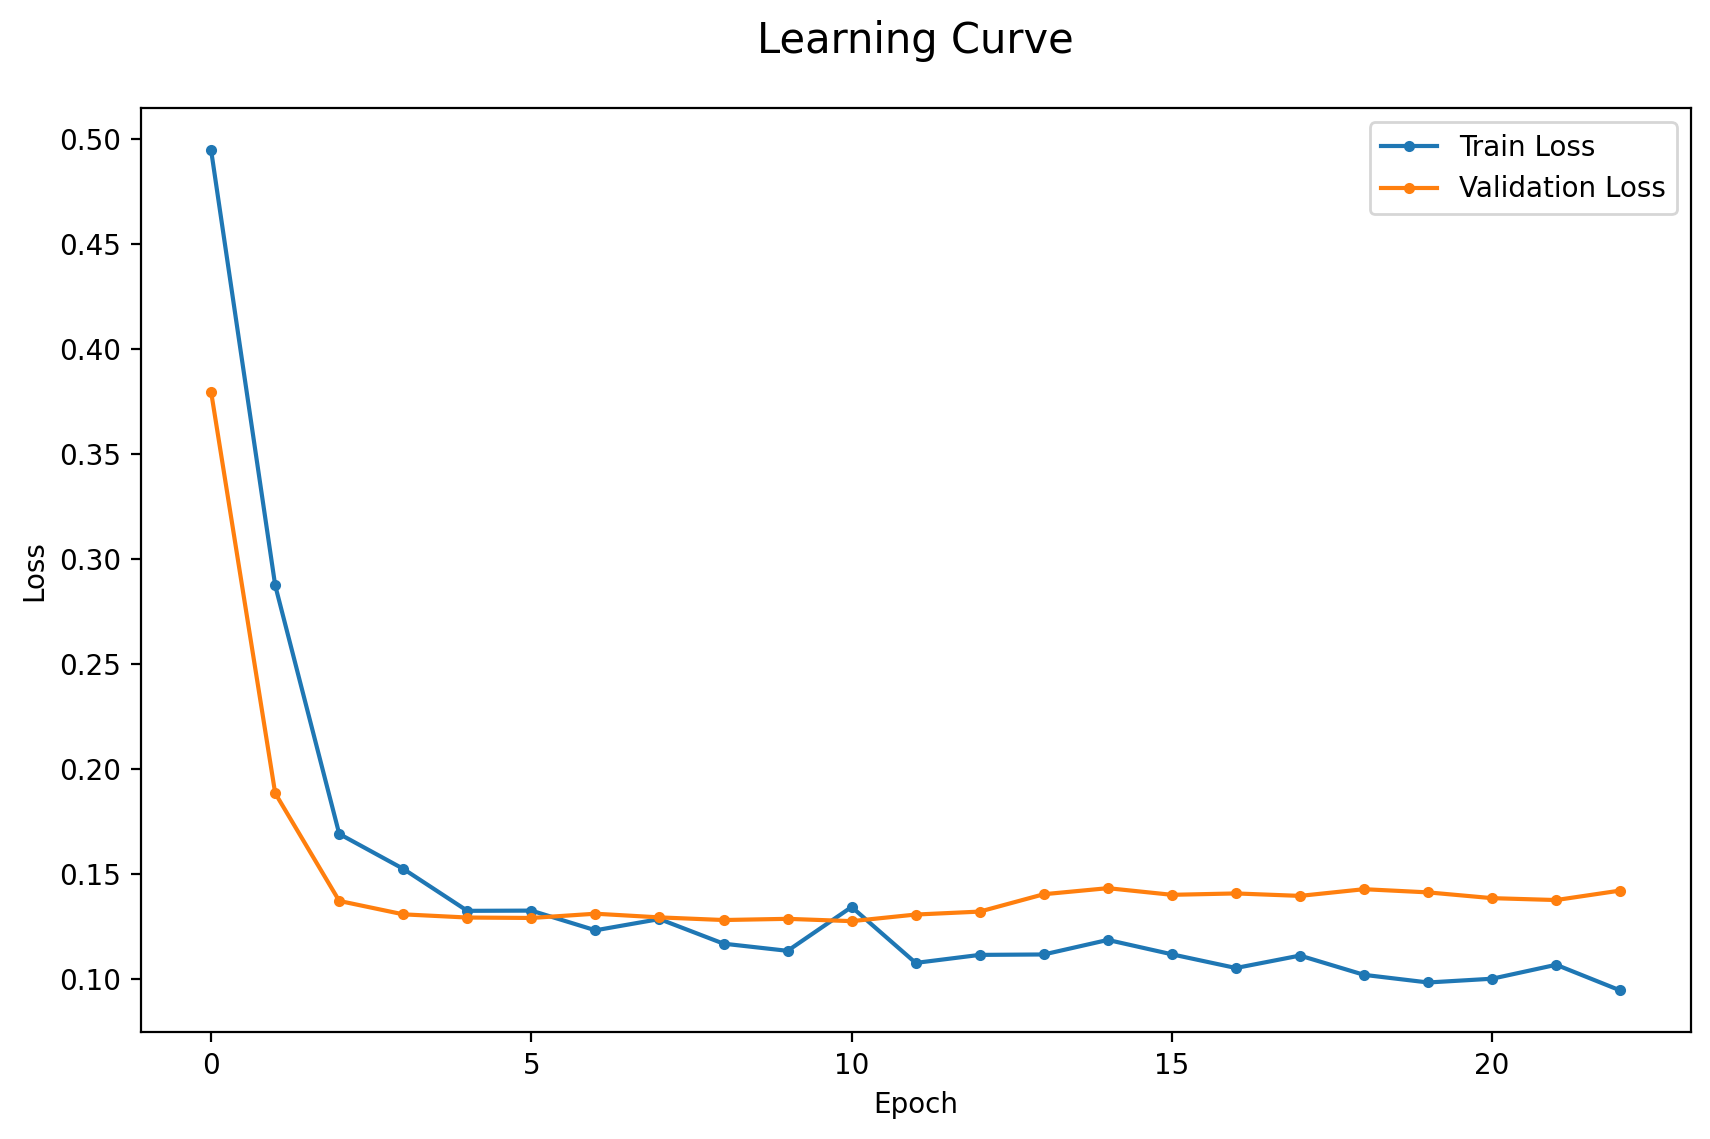

In [25]:
# 학습 곡선
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [26]:
# 예측
y_pred = model.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)

# 평가
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[[183   8]
 [ 14 145]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       191
           1       0.95      0.91      0.93       159

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350



In [29]:
# 의견
# 기본 모델의 앞쪽 레이어 일부를 동결, 후반부 레이어 및 새롭게 추가한 레이어를 학습하도록 미세조정 했다.
# 그 결과 정확도는 향상되었으며, 클래스 0, 1 모두 precision, recall, f1-score가 우수하게 나타났다.
# 오분류도 비슷하게 나타나, 높은 정확도 뿐만 아니라 클래스 간 균형 잡힌 예측 성능도 확인되었다.
# 따라서, fine-tuning을 적용한 모델이 가장 우수한 성능을 보였다고 판단된다.